In [3]:
%pip install crunch-cli --upgrade --quiet --progress-bar off
!crunch setup-notebook structural-break-real-time HOI1aJKOA3JNdFX4YmwZJbYZ

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


crunch-cli, version 12.0.1
delete d:\breakdown_1\files\.crunchdao
you appear to have never submitted code before
data\X_train.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/234/X_train.parquet (218514418 bytes)
data\X_test.reduced.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/234/X_test.reduced.parquet (2587435 bytes)
data\y_train.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/234/y_train.parquet (8356193 bytes)
data\y_test.reduced.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/234/y_test.reduced.parquet (106299 bytes)
data\y_test_index.reduced.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/234/y_test_index.reduced.parquet (3674 bytes)
data\y_train_index.parquet: download from https:crunchdao--c


  0%|          | 0.00/219M [00:00<?, ?iB/s]
  0%|          | 81.9k/219M [00:00<04:45, 766kiB/s]
  0%|          | 197k/219M [00:00<04:47, 758kiB/s] 
  0%|          | 393k/219M [00:00<03:07, 1.17MiB/s]
  0%|          | 623k/219M [00:00<02:21, 1.54MiB/s]
  0%|          | 934k/219M [00:00<01:46, 2.05MiB/s]
  1%|          | 1.36M/219M [00:00<01:18, 2.75MiB/s]
  1%|          | 1.72M/219M [00:00<01:12, 2.98MiB/s]
  1%|          | 2.05M/219M [00:00<01:12, 3.00MiB/s]
  1%|          | 2.52M/219M [00:00<01:02, 3.47MiB/s]
  1%|▏         | 3.01M/219M [00:01<00:56, 3.84MiB/s]
  2%|▏         | 3.49M/219M [00:01<00:52, 4.06MiB/s]
  2%|▏         | 3.90M/219M [00:01<00:55, 3.84MiB/s]
  2%|▏         | 4.29M/219M [00:01<00:56, 3.80MiB/s]
  2%|▏         | 4.77M/219M [00:01<00:52, 4.06MiB/s]
  2%|▏         | 5.24M/219M [00:01<00:50, 4.23MiB/s]
  3%|▎         | 5.67M/219M [00:01<00:50, 4.20MiB/s]
  3%|▎         | 6.19M/219M [00:01<00:47, 4.49MiB/s]
  3%|▎         | 6.65M/219M [00:01<00:48, 4.37MiB/s]
  3%|▎

In [4]:
import math
import os
from typing import Iterable, List, Optional, Tuple

# Import your dependencies.
import joblib
import numpy as np
import pandas as pd
import pywt
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import HistGradientBoostingClassifier
from scipy.stats import ks_2samp, skew
from scipy.signal import welch

In [5]:
import crunch

# Load the Crunch Toolings (data loader, local tester, submitter).
crunch_tools = crunch.load_notebook()

d:\breakdown_1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loaded crunch tools for module: <module '__main__'>

cli version: 12.0.1
available ram: 7.42 gb
available cpu: 16 core
----


In [7]:
train_data, test_data = crunch_tools.load_data()

data\X_train.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/234/X_train.parquet (218514418 bytes)
data\X_train.parquet: already exists, file length match
data\X_test.reduced.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/234/X_test.reduced.parquet (2587435 bytes)
data\X_test.reduced.parquet: already exists, file length match
data\y_train.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/234/y_train.parquet (8356193 bytes)
data\y_train.parquet: already exists, file length match
data\y_test.reduced.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/234/y_test.reduced.parquet (106299 bytes)
data\y_test.reduced.parquet: already exists, file length match
data\y_test_index.reduced.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws

In [ ]:
for dataset_id, x_hist, x_online, tau in train_data:
    if tau is not None and 50 <= tau <= len(x_online) - 50:
        break

x_hist   = np.asarray(x_hist)
x_online = np.asarray(x_online)

print(f"      series id: {dataset_id}")
print(f"historical size: {len(x_hist)}")
print(f"    online size: {len(x_online)}")
print(f"   break at tau: {tau}   (None means no break)")

In [ ]:
train_data = train_data[:100]



100

In [9]:
!pip install statsmodels


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose


In [31]:
time_series_data

array([-2.03577637e-01,  7.80245672e-01,  1.67508294e+00,  1.64889714e+00,
        1.78860925e+00,  1.49099205e-01,  2.07007055e-01,  1.10128408e-01,
        1.09639391e+00,  1.51437602e-01, -4.82684334e-01, -7.99208308e-02,
       -2.68607120e-01, -1.27500642e+00, -1.33816064e+00, -1.04249831e+00,
       -1.46308279e+00, -5.29077579e-02,  3.99271205e-01, -2.06119360e-02,
       -4.18823773e-01,  4.95009987e-01, -3.83675551e-01,  1.82512995e-01,
        2.18095172e-01,  1.57595487e+00,  5.26413554e-01,  1.39580736e+00,
        1.18394251e+00,  1.10204036e-01, -6.18564275e-01, -1.19315517e+00,
       -9.43190284e-01, -1.18424668e+00, -6.87732061e-01, -9.19735217e-01,
       -9.04139357e-01, -3.66801312e-01, -6.52452065e-01, -3.79814587e-01,
        2.66060980e-01,  7.91249829e-01,  1.85705553e+00,  8.41675878e-01,
        1.30350187e+00,  1.32435867e+00,  5.66338114e-01, -3.41813970e-02,
        1.01346194e-01, -7.56347073e-01, -3.72633795e-02, -3.01157040e-01,
        6.02852417e-01, -

In [32]:
# len(train_data[0][0])
time_series_data = pd.Series(
    temp_data,
    index=pd.date_range(start="2000-01-01", periods=len(temp_data), freq="D")
)

decomposition = seasonal_decompose(
    time_series_data,
    model="additive",   # switch from multiplicative — your values go negative
    period=50            # set explicitly; freq="D" alone won't tell it the cycle length
)


In [8]:
decomposition

NameError: name 'decomposition' is not defined

In [34]:
trend    = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

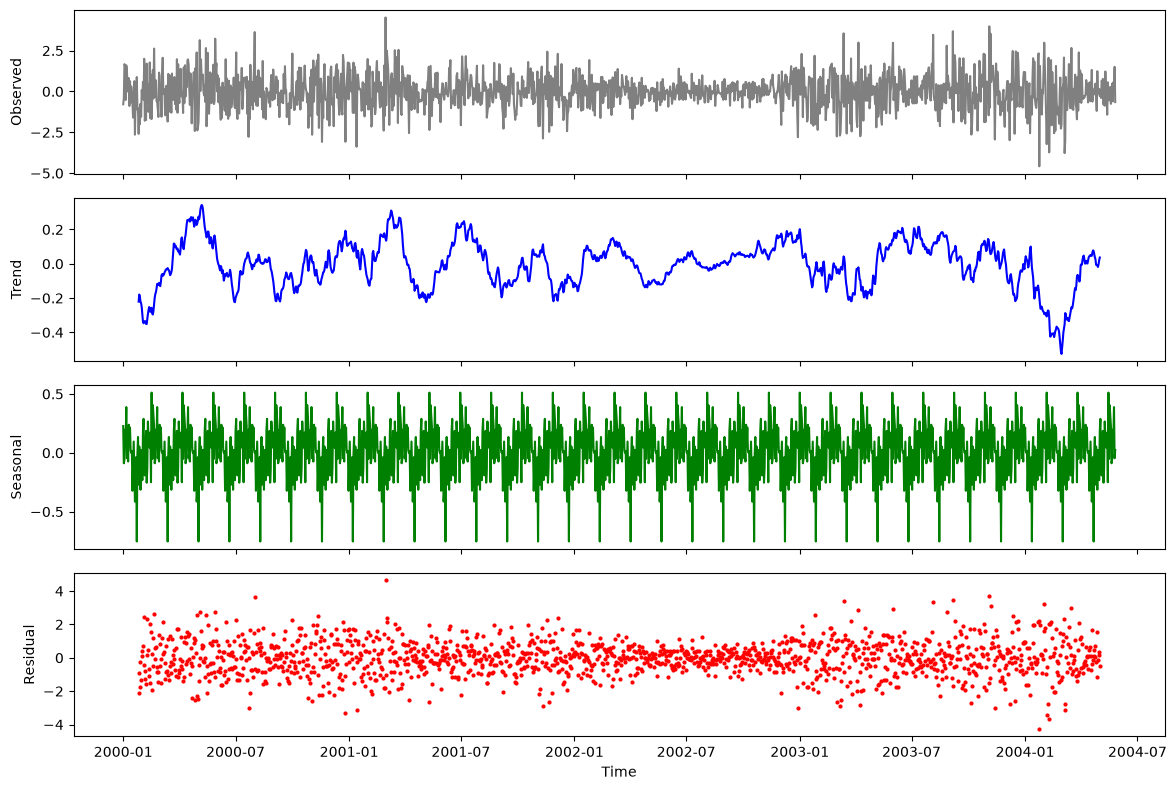

In [35]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

axes[0].plot(time_series_data, color='gray')
axes[0].set_ylabel('Observed')

axes[1].plot(trend, color='blue')
axes[1].set_ylabel('Trend')

axes[2].plot(seasonal, color='green')
axes[2].set_ylabel('Seasonal')

axes[3].plot(residual, color='red', marker='o', linestyle='none', markersize=2)
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Time')

plt.tight_layout()
plt.show()


In [15]:
train_data[110][3]

np.int64(348)

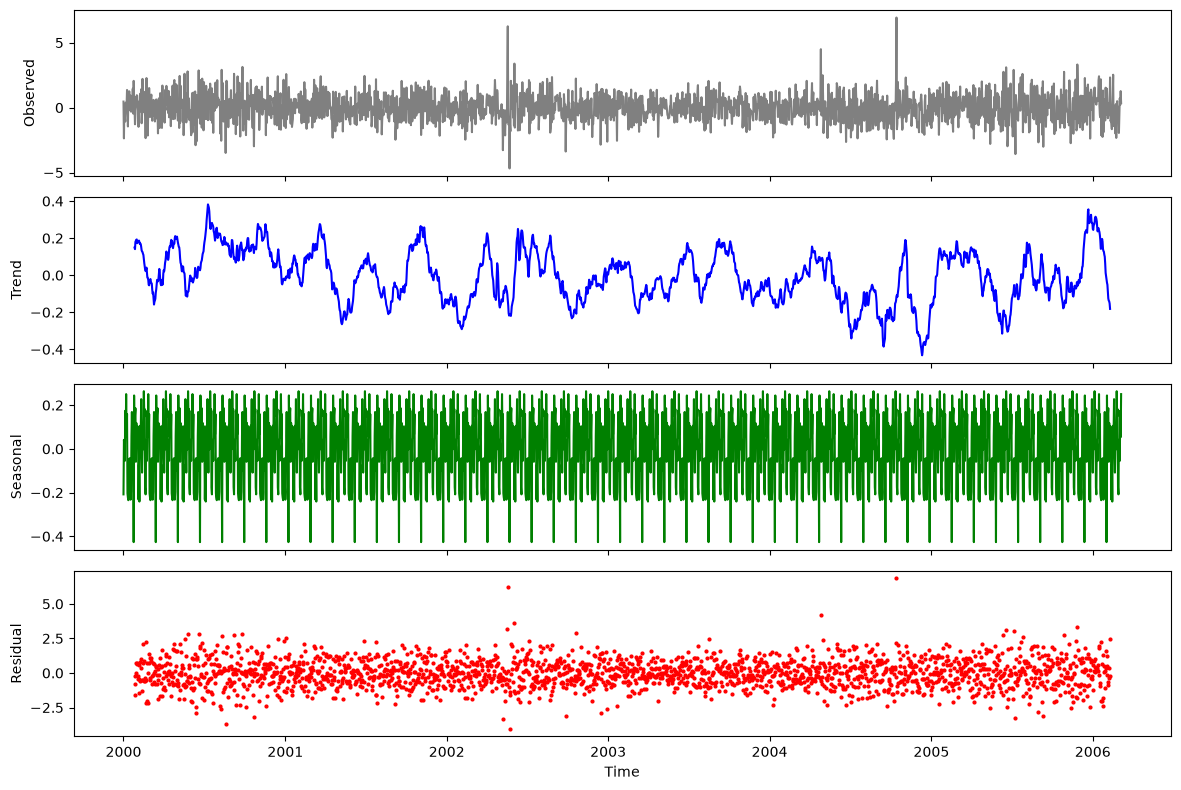

In [16]:
temp_data = list(train_data[110][1]) + list(train_data[110][2])

time_series_data = pd.Series(
    temp_data,
    index=pd.date_range(start="2000-01-01", periods=len(temp_data), freq="D")
)

decomposition = seasonal_decompose(
    time_series_data,
    model="additive",   # switch from multiplicative — your values go negative
    period=50            # set explicitly; freq="D" alone won't tell it the cycle length
)


trend    = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

axes[0].plot(time_series_data, color='gray')
axes[0].set_ylabel('Observed')

axes[1].plot(trend, color='blue')
axes[1].set_ylabel('Trend')

axes[2].plot(seasonal, color='green')
axes[2].set_ylabel('Seasonal')

axes[3].plot(residual, color='red', marker='o', linestyle='none', markersize=2)
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Time')

plt.tight_layout()
plt.show()


In [12]:
from scipy.fft import fft, fftfreq

In [ ]:
temp_data = list(train_data[0][1]) + list(train_data[0][2])

temp_data


1608

In [ ]:
time_series_data = temp_data

1608

In [ ]:
fft_values = fft(time_sereis_data)
frequencies = fftfreq*N, 

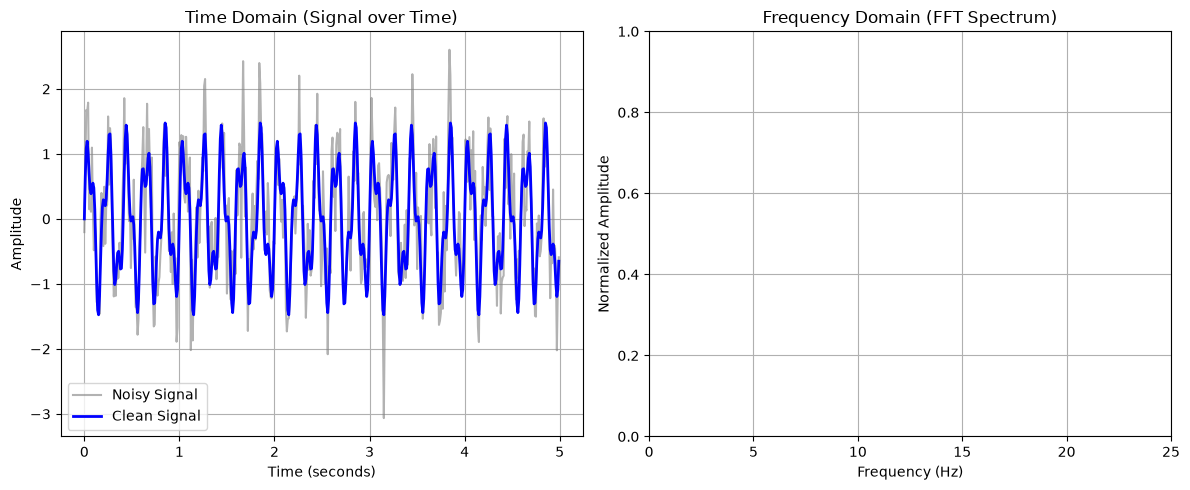

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.fft import fft, fftfreq

# # 1. Generate a dummy time series signal
# sample_rate = 100  # Data points per second (Hz)
# duration = 5       # Duration in seconds
# N = sample_rate * duration  # Total samples

# t = np.linspace(0, duration, N, endpoint=False)

# # Signal = 5 Hz wave + 12 Hz wave + Random noise
# pure_signal = np.sin(2 * np.pi * 5 * t) + 0.5 * np.sin(2 * np.pi * 12 * t)
# noise = np.random.normal(0, 0.5, N)
# time_series_data = pure_signal + noise

# # 2. Compute the Fast Fourier Transform (FFT)
# fft_values = fft(time_series_data)
# frequencies = fftfreq(N, 1 / sample_rate)

# # Extract positive frequencies and normalize amplitude
# positive_frequencies = frequencies[:N // 2]
# amplitudes = (2.0 / N) * np.abs(fft_values[:N // 2])

# # 3. Plot the Results
# plt.figure(figsize=(12, 5))

# # Plot 1: Time Domain (Original Signal)
# plt.subplot(1, 2, 1)
# plt.plot(t, time_series_data, color='gray', alpha=0.6, label='Noisy Signal')
# plt.plot(t, pure_signal, color='blue', label='Clean Signal', linewidth=2)
# plt.title('Time Domain (Signal over Time)')
# plt.xlabel('Time (seconds)')
# plt.ylabel('Amplitude')
# plt.legend()
# plt.grid(True)

# # Plot 2: Frequency Domain (FFT Spectrum)
# plt.subplot(1, 2, 2)
# # plt.stem(positive_frequencies, amplitudes, use_line_collection=True, linefmt='r-', markerfmt='ro', basefmt=' ')
# plt.title('Frequency Domain (FFT Spectrum)')
# plt.xlabel('Frequency (Hz)')
# plt.ylabel('Normalized Amplitude')
# plt.xlim(0, 25)  # Zooming in on relevant frequencies
# plt.grid(True)

# plt.tight_layout()
# plt.show()


In [ ]:
# for dataset_id, x_hist, x_online. tau in train_data:
#     if data_counter == 100 and data_t = data_nt:
#         break
